## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# ==================================================
# Standard libraries
# ==================================================

import warnings
import random
import sys
import importlib
from pathlib import Path


# ==================================================
# Data handling
# ==================================================

import numpy as np
import pandas as pd


# ==================================================
# Visualization
# ==================================================

import matplotlib.pyplot as plt 
from matplotlib.lines import Line2D
from IPython.display import display, HTML, Markdown


# ==================================================
# Time series analysis
# ==================================================

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch.unitroot import KPSS


# ==================================================
# Machine learning
# ==================================================

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor



# ==================================================
# Model saving
# ==================================================

import joblib


# ==================================================
# Global settings
# ==================================================

warnings.filterwarnings("ignore")

np.random.seed(42)
random.seed(42)


# ==================================================
# Add project root to path
# ==================================================

sys.path.append("..")


# ==================================================
# Import bundeshost modules
# ==================================================

import bundeshost.config
import bundeshost.data_pipeline
import bundeshost.feature_engineering
import bundeshost.predict
import bundeshost.train


# ==================================================
# Reload modules (for notebook development)
# ==================================================

importlib.reload(bundeshost.config)
importlib.reload(bundeshost.data_pipeline)
importlib.reload(bundeshost.feature_engineering)
importlib.reload(bundeshost.predict)
importlib.reload(bundeshost.train)

# ==================================================
# Import functions after reload
# ==================================================

from bundeshost.data_pipeline import (
    get_tourism_data
)

from bundeshost.feature_engineering import (
    build_state_series,
    create_corona_dummy
)

from bundeshost.config import (
    MODEL_DIR,
    MODEL_ORDERS
)


# ==================================================
# Global Forecasting Settings
# ==================================================

TEST_SIZE = 12  # Last 12 months as test set

In [3]:
# ==================================================
# Global color map for all models
# ==================================================

COLOR_MAP = {"SARIMA": "#2A9D8F",
            "SARIMAX": "#8FD5C7"
            }

In [4]:
# ==================================================
# Load data
# ==================================================

df = get_tourism_data()

print(df.shape)
df.head()

(6528, 4)


metric,date,state,arrivals,overnight
0,1992-01-01,Baden-Württemberg,600440.0,2217561.0
1,1992-02-01,Baden-Württemberg,721432.0,2463814.0
2,1992-03-01,Baden-Württemberg,813015.0,2788980.0
3,1992-04-01,Baden-Württemberg,973059.0,3363530.0
4,1992-05-01,Baden-Württemberg,1229069.0,4079477.0


## Helper Functions

In [6]:
# ==================================================
# Plotting Helpers (Notebook only)
# ==================================================

def acf1(
    x,
    nlags=24,
    acf_type='correlation',
    pacf=False,
    ax=None,
    return_values=False,
    **kwargs
):

    lags = np.arange(1, nlags + 1)

    if pacf:
        if acf_type == 'correlation':
            values = sm.tsa.pacf(x, nlags=nlags)[1:]
            ylabel = 'PACF'
    else:
        if acf_type == 'correlation':
            values = sm.tsa.acf(x, nlags=nlags, fft=False)[1:]
            ylabel = 'ACF'
        elif acf_type == 'covariance':
            values = sm.tsa.acovf(x, nlag=nlags)[1:]
            ylabel = 'ACoV'

    if return_values:
        return lags, values

    if ax is None:
        ax = plt.gca()

    ax.bar(lags, values, **kwargs)
    ax.axhline(0, color='black', linewidth=1)

    if acf_type == 'correlation':
        conf_level = 1.96 / np.sqrt(len(x))
        ax.axhline(conf_level, color='red', linestyle='--', linewidth=1)
        ax.axhline(-conf_level, color='red', linestyle='--', linewidth=1)

    ax.set_xlabel('LAG')
    ax.set_ylabel(ylabel)

    return ax

# ==================================================
# Plot: Zoomed View (Last n Years)
# ==================================================

def plot_forecast_zoom(
    train,
    test,
    forecast,
    state_name,
    model_name,
    n_years=3,
    lower_ci=None,
    upper_ci=None
):

    n_months = n_years * 12
    color = COLOR_MAP.get(model_name, "red")

    plt.figure(figsize=(12, 6))

    # Training data (last n years)
    plt.plot(
        train.index[-n_months:],
        train[-n_months:],
        color="black",
        linewidth=1.5,
        marker="o",
        markersize=4,
        markerfacecolor="none",
        label=f"Training Data (Last {n_years} Years)"
    )

    # Test data
    plt.plot(
        test.index,
        test,
        color="black",
        linestyle="--",
        marker="o",
        markersize=5,
        markerfacecolor="none",
        label="Test Data"
    )

    # Forecast
    plt.plot(
        forecast.index,
        forecast,
        color=color,
        linestyle="--",
        marker="o",
        markersize=5,
        markerfacecolor="none",
        label="Forecast"
    )

    # Confidence interval (optional)
    if lower_ci is not None:
        plt.fill_between(
            forecast.index,
            lower_ci,
            upper_ci,
            color=color,
            alpha=0.15,
            label="Confidence Interval"
        )

    # Connect last train to first test
    plt.plot(
        [train.index[-1], test.index[0]],
        [train.iloc[-1], test.iloc[0]],
        linestyle="--",
        color="gray",
        linewidth=1
    )

    plt.title(
        f"{model_name} Forecast – {state_name} (Last {n_years} Years)",
        fontsize=13
    )

    plt.xlabel("Date")
    plt.ylabel("Arrivals")

    plt.grid(alpha=0.3)
    plt.legend(frameon=False, loc="upper left")
    plt.tight_layout()
    plt.show()


# ==================================================
# Evaluation utilities
# ==================================================

def evaluate_forecast(y_true, y_pred):

    # Align indices
    y_true, y_pred = y_true.align(y_pred, join="inner")

    y_true = y_true.values
    y_pred = y_pred.values

    # Avoid division by zero
    mask = y_true != 0

    mape = np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100

    mae = np.mean(np.abs(y_true - y_pred))

    return mape, mae



## Model Containers

In [7]:
# ==================================================
# Notebook-only containers
# ==================================================

# Metrics per model
sarima_metrics = {}
sarimax_metrics = {}

## Load Data Pipeline + Show States

In [8]:
# ==================================================
# Load dataset
# ==================================================

df = get_tourism_data()

print("Shape:", df.shape)
display(df.head())


# ==================================================
# Available states
# ==================================================

states = sorted(df["state"].unique())

print("Available states:")
display(states)

Shape: (6528, 4)


metric,date,state,arrivals,overnight
0,1992-01-01,Baden-Württemberg,600440.0,2217561.0
1,1992-02-01,Baden-Württemberg,721432.0,2463814.0
2,1992-03-01,Baden-Württemberg,813015.0,2788980.0
3,1992-04-01,Baden-Württemberg,973059.0,3363530.0
4,1992-05-01,Baden-Württemberg,1229069.0,4079477.0


Available states:


['Baden-Württemberg',
 'Bayern',
 'Berlin',
 'Brandenburg',
 'Bremen',
 'Hamburg',
 'Hessen',
 'Mecklenburg-Vorpommern',
 'Niedersachsen',
 'Nordrhein-Westfalen',
 'Rheinland-Pfalz',
 'Saarland',
 'Sachsen',
 'Sachsen-Anhalt',
 'Schleswig-Holstein',
 'Thüringen']

## Select State & Build Time Series

In [57]:
print("🚀 Running full pipeline from here...")

🚀 Running full pipeline from here...


In [718]:
# ==================================================
# Select state
# ==================================================

state_name = "Thüringen"   # change to analyze another state

x_ts = build_state_series(df, state_name)

print(f"Selected state: {state_name}")
print(f"Date range: {x_ts.index.min()} → {x_ts.index.max()}")
print(f"Observations: {len(x_ts)}")

display(x_ts.head())

Selected state: Thüringen
Date range: 1992-01-01 00:00:00 → 2025-12-01 00:00:00
Observations: 408


date
1992-01-01     82432.0
1992-02-01    107066.0
1992-03-01    112065.0
1992-04-01    134258.0
1992-05-01    195720.0
Freq: MS, dtype: float64

## Visualize Time Series

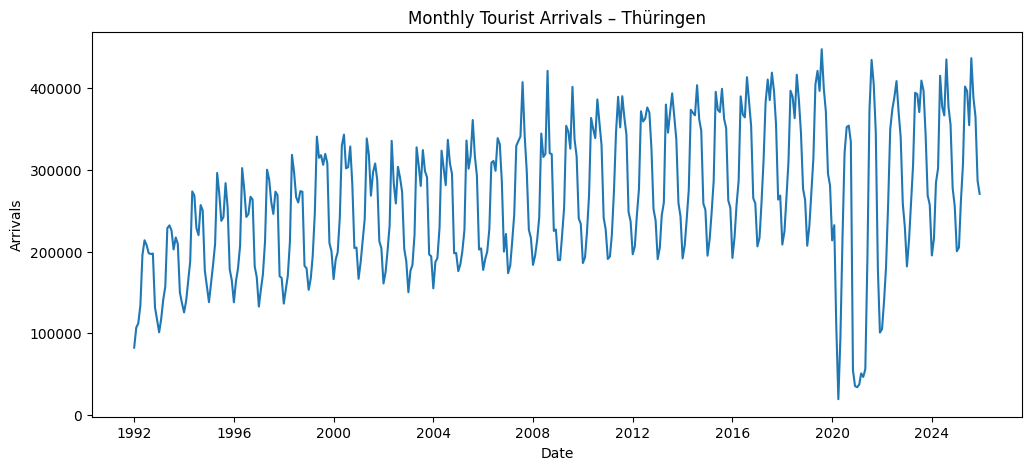

In [719]:
## Quick Visualization (EDA only)

plt.figure(figsize=(12,5))
plt.plot(x_ts)
plt.title(f"Monthly Tourist Arrivals – {state_name}")
plt.xlabel("Date")
plt.ylabel("Arrivals")
plt.show()

## Stationarity Test X_t 

In [720]:
# --------------------------------------------------
# Test stationarity of X_t using KPSS

kpss_test = KPSS(x_ts)
p_value = kpss_test.pvalue

# Print the results
print(f'p-value: {p_value:.3f}\n')

# Interpret the results
alpha = 0.05
if p_value >= alpha:
     print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else: 
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')

p-value: 0.000

The time series is not stationary (reject "H0: The time series is stationary" at a 5% significance level).


## First Difference

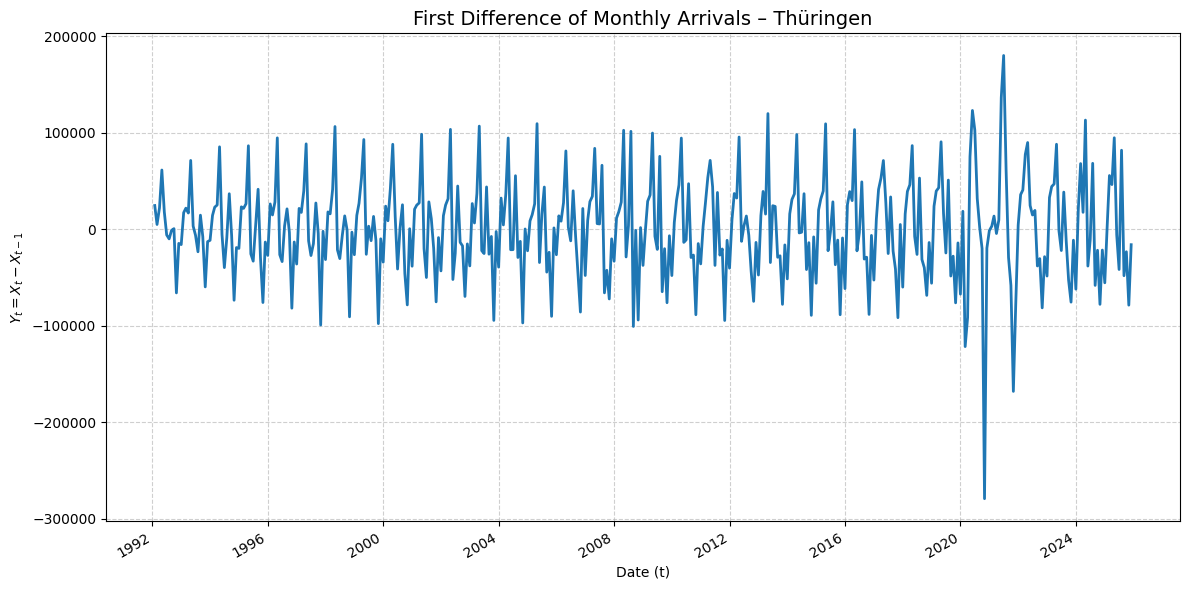

In [721]:
# --------------------------------------------------
# First difference: Y_t = X_t - X_{t-1} (d = 1)

y_ts = x_ts.diff().dropna()


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(y_ts, linewidth=2)

ax.set_title(f"First Difference of Monthly Arrivals – {state_name}", fontsize=14)
ax.set_xlabel("Date (t)")
ax.set_ylabel(r"$Y_t = X_t - X_{t-1}$")

ax.grid(True, linestyle="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Stationarity Test Y_t 

In [722]:
# --------------------------------------------------
# Test stationarity of Y_t using KPSS

kpss_test = KPSS(y_ts)
p_value = kpss_test.pvalue

# Print the results
print(f'p-value: {p_value:.3f}\n')

# Interpret the results
alpha = 0.05
if p_value >= alpha:
     print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else: 
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')

p-value: 0.998

The time series is stationary (fail to reject "H0: The time series is stationary" at a 5% significance level).


## Train / Test Split

In [723]:
# --------------------------------------------------
# Train-test split for time series (last N months as test set)

def train_test_split_ts(ts, test_size=TEST_SIZE):
    
    # Split training portion (all except last test_size observations)
    train = ts.iloc[:-test_size]
    
    # Split test portion (last test_size observations)
    test = ts.iloc[-test_size:]
    
    return train, test

In [724]:
# --------------------------------------------------
# Apply train-test split

train_ts, test_ts = train_test_split_ts(x_ts)

print(f"Training observations: {len(train_ts)}")
print(f"Test observations: {len(test_ts)}")

Training observations: 396
Test observations: 12


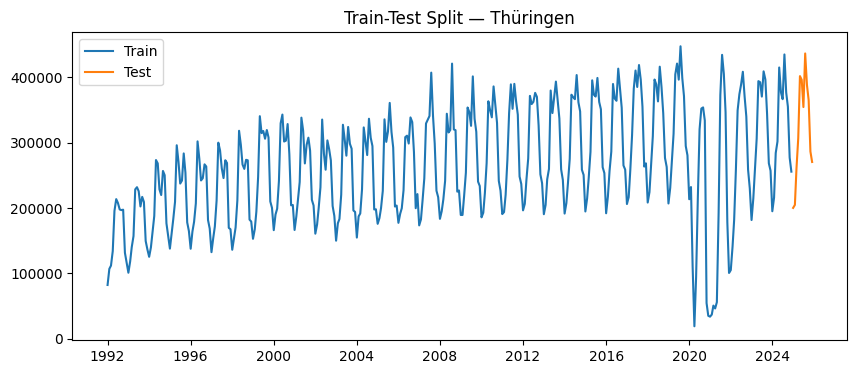

In [725]:
# ==================================================
# Quick split visualization
# ==================================================

plt.figure(figsize=(10,4))

plt.plot(train_ts, label="Train")
plt.plot(test_ts, label="Test")

plt.legend()
plt.title(f"Train-Test Split — {state_name}")

plt.show()

## ACF and PACF of First-Differenced Series

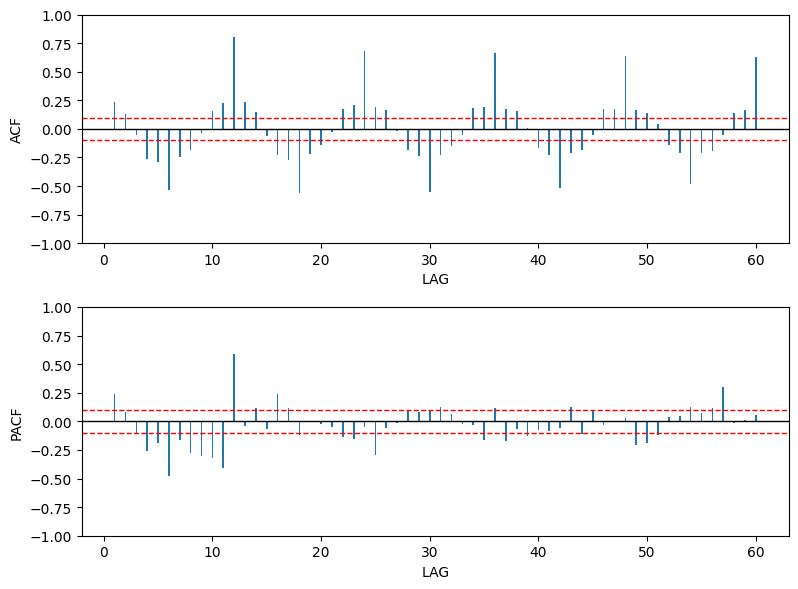

In [726]:
# ==================================================
# First difference: (1 - B)U1_t
# ==================================================

diff1 = train_ts.diff().dropna()

fig, axes = plt.subplots(nrows=2, figsize=(8,6))

acf1(diff1, nlags=60, ax=axes[0], width=0.15)
axes[0].set_ylim(-1, 1)

acf1(diff1, nlags=60, ax=axes[1], width=0.15, pacf=True)
axes[1].set_ylim(-1, 1)

fig.tight_layout()
plt.show()

## ACF and PACF of Seasonally Differenced Series

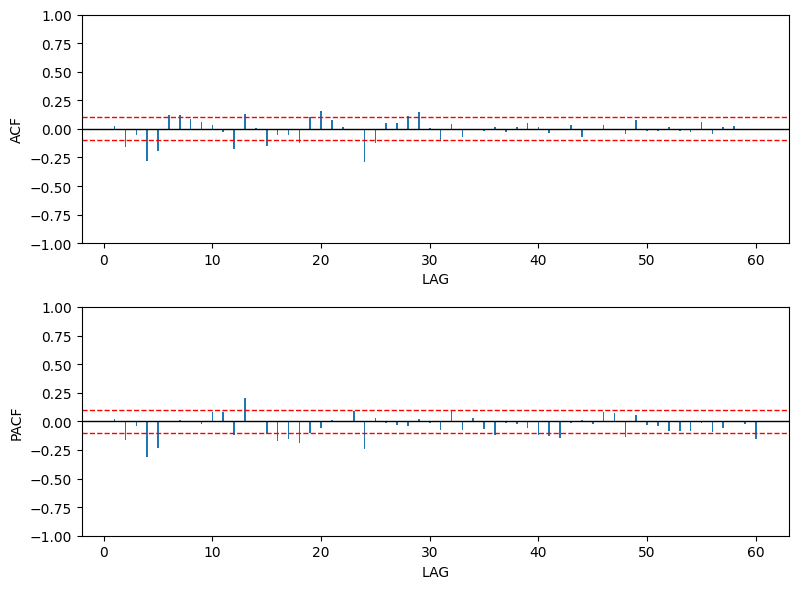

In [727]:
# ==================================================
# Seasonal difference: (1 - B^12)(1 - B)U1_t
# ==================================================

diff_seasonal = diff1.diff(12).dropna()

fig, axes = plt.subplots(nrows=2, figsize=(8,6))

acf1(diff_seasonal, nlags=60, ax=axes[0], width=0.15)
axes[0].set_ylim(-1, 1)

acf1(diff_seasonal, nlags=60, ax=axes[1], width=0.15, pacf=True)
axes[1].set_ylim(-1, 1)

fig.tight_layout()
plt.show()

## Selected SARIMA/SARIMAX Orders for Each State

Based on the inspection of the ACF and PACF plots of the differenced and seasonally differenced series for each state, appropriate SARIMA orders were determined.

By changing the selected state and examining the corresponding ACF and PACF patterns, suitable values for the non-seasonal parameters $(p,d,q)$ and the seasonal parameters $(P,D,Q)$ with seasonal period $s=12$ were identified.

The same autoregressive structure is used for both SARIMA and SARIMAX models. In the SARIMAX specification, the model additionally includes exogenous variables while keeping the same $(p,d,q)(P,D,Q,12)$ structure.

In [728]:
importlib.reload(bundeshost.config)
print("Selected orders:")
print( state_name )
print(bundeshost.config.MODEL_ORDERS[state_name])

Selected orders:
Thüringen
{'sarima': ((1, 1, 2), (1, 1, 1, 12)), 'sarimax': ((1, 1, 2), (1, 1, 1, 12))}


## 1. SARIMA Model
A SARIMA model is fitted to the training series \(U_{1,t}\) using the previously selected orders for the chosen state.

In [729]:
# --------------------------------------------------
# Train SARIMA model

def train_sarima(train_series, order, seasonal_order):

    # Fit SARIMA model
    model = sm.tsa.arima.ARIMA(
        train_series,
        order=order,
        seasonal_order=seasonal_order
    ).fit(method_kwargs={'maxiter': 500})

    return model

In [730]:
# --------------------------------------------------
# Get SARIMA orders (allow manual override for debugging)

USE_MANUAL_SARIMA = False

if USE_MANUAL_SARIMA:
    
    order = (1, 1, 2)
    seasonal_order = (1, 1, 1, 12)

else:
    
    order, seasonal_order = bundeshost.config.MODEL_ORDERS[state_name]["sarima"]

print(f"Using SARIMA order: {order} and seasonal order: {seasonal_order}")

Using SARIMA order: (1, 1, 2) and seasonal order: (1, 1, 1, 12)


In [731]:
# --------------------------------------------------
# Train model

sarima_model = train_sarima(train_ts, order, seasonal_order)

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               None   No. Observations:                  396
Model:             ARIMA(1, 1, 2)x(1, 1, [1], 12)   Log Likelihood               -4435.837
Date:                            Thu, 14 May 2026   AIC                           8883.674
Time:                                    21:43:21   BIC                           8907.362
Sample:                                01-01-1992   HQIC                          8893.071
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5647      0.058      9.800      0.000       0.452       0.678
ma.L1         -0.5784      0.063   

### 1.1 SARIMA Forecasting and Model Evaluation

In [732]:
# ==================================================
# Generate SARIMA forecast
# ==================================================

def forecast_sarima(model, horizon):

    res = model.get_forecast(steps=horizon)

    mean = res.predicted_mean
    conf = res.conf_int()

    forecast_df = pd.DataFrame({
        "forecast": mean,
        "lower_ci": conf.iloc[:, 0],
        "upper_ci": conf.iloc[:, 1],
    })

    return forecast_df

In [733]:
# --------------------------------------------------
# Generate forecast for the test set horizon

sarima_df = forecast_sarima(
    sarima_model,
    TEST_SIZE
)

In [734]:
# ==================================================
# Evaluate SARIMA forecast
# ==================================================

mape_sarima, mae_sarima = evaluate_forecast(
    test_ts,
    sarima_df["forecast"]
)

sarima_metrics[state_name] = {
    "MAPE": mape_sarima,
    "MAE": mae_sarima
}

print(f"MAPE: {mape_sarima:.2f}%")
print(f"MAE: {mae_sarima:,.0f}")

MAPE: 3.85%
MAE: 11,681


### 1.2 SARIMA Forecast Visualization

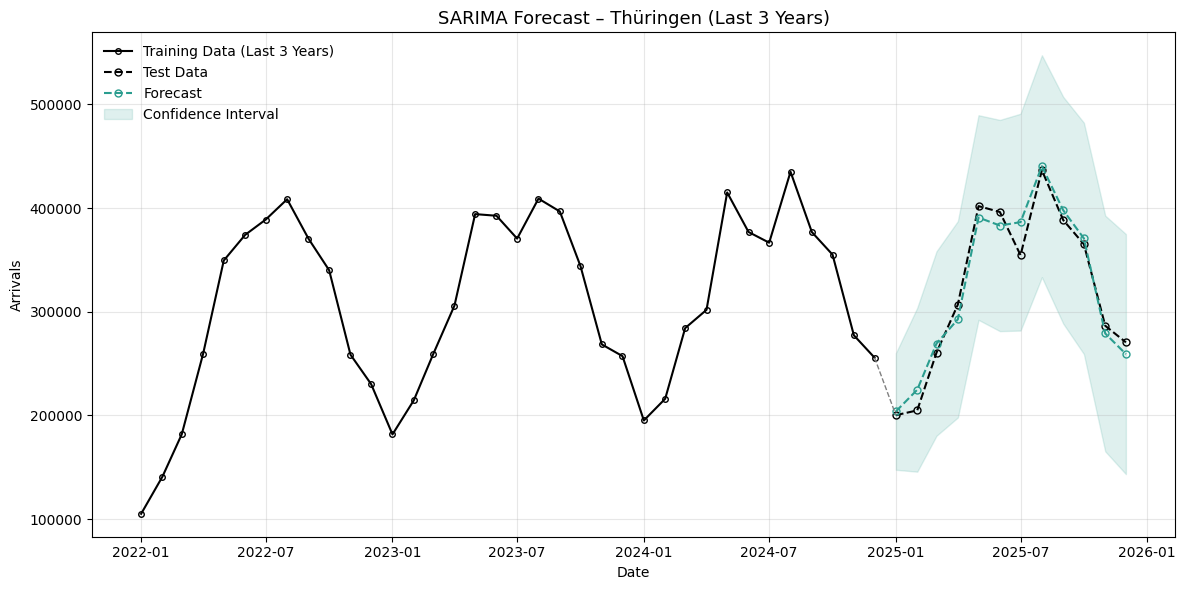

In [735]:
# ==================================================
# Plot SARIMA forecast (zoomed view)
# ==================================================

plot_forecast_zoom(
    train_ts,
    test_ts,
    sarima_df["forecast"],
    state_name,
    "SARIMA",
    lower_ci=sarima_df["lower_ci"],
    upper_ci=sarima_df["upper_ci"]
)

## 2. SARIMAX Model with COVID-19 Dummy Variable

### 2.1 Create COVID dummy variable

In [736]:
# ==================================================
# Exogenous variable for SARIMAX (COVID dummy)
# ==================================================

corona_dummy = create_corona_dummy(x_ts.index)


# ==================================================
# Train / test split for exogenous variable
# ==================================================

exog_train = corona_dummy.iloc[:-TEST_SIZE]
exog_test  = corona_dummy.iloc[-TEST_SIZE:]

print("Train COVID months:", exog_train.sum())

Train COVID months: 15


In [737]:
print("Train range:", exog_train.index.min(), "→", exog_train.index.max())
print("Test range :", exog_test.index.min(), "→", exog_test.index.max())

Train range: 1992-01-01 00:00:00 → 2024-12-01 00:00:00
Test range : 2025-01-01 00:00:00 → 2025-12-01 00:00:00


### 2.2 train SARIMAX function

In [738]:
# ==================================================
# Train SARIMAX model
# ==================================================

def train_sarimax(train_series, exog_train, order, seasonal_order):

    model = sm.tsa.statespace.SARIMAX(
        train_series,
        exog=exog_train,
        order=order,
        seasonal_order=seasonal_order
    ).fit(disp=False, maxiter=500)

    return model

### 2.3 Get SARIMAX orders

In [739]:
# ==================================================
# SARIMAX orders
# ==================================================

USE_MANUAL_SARIMAX = False
if USE_MANUAL_SARIMAX:

    order = (2, 1, 1)
    seasonal_order = (1, 1, 1, 12)

else:

    order, seasonal_order = bundeshost.config.MODEL_ORDERS[state_name]["sarimax"]

print("SARIMAX order:", order)
print("Seasonal order:", seasonal_order)

SARIMAX order: (1, 1, 2)
Seasonal order: (1, 1, 1, 12)


### 2.4 Train SARIMAX model

In [740]:
# ==================================================
# Train SARIMAX
# ==================================================

sarimax_model = train_sarimax(
    train_ts,
    exog_train,
    order,
    seasonal_order
)

print(sarimax_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 None   No. Observations:                  396
Model:             SARIMAX(1, 1, 2)x(1, 1, [1], 12)   Log Likelihood               -4396.881
Date:                              Thu, 14 May 2026   AIC                           8807.761
Time:                                      21:43:22   BIC                           8835.397
Sample:                                  01-01-1992   HQIC                          8818.724
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
corona_dummy -1.054e+05   6678.621    -15.789      0.000   -1.19e+05   -9.24e+04
ar.L1        

### 2.5 SARIMAX Forecasting and Model Evaluation

In [741]:
# ==================================================
# Generate SARIMAX forecast
# ==================================================

def forecast_sarimax(model, exog_future, horizon):

    res = model.get_forecast(
        steps=horizon,
        exog=exog_future
    )

    mean = res.predicted_mean
    conf = res.conf_int()

    forecast_df = pd.DataFrame({
        "forecast": mean,
        "lower_ci": conf.iloc[:, 0],
        "upper_ci": conf.iloc[:, 1],
    })

    return forecast_df

In [742]:
# ==================================================
# Generate forecast for test horizon
# ==================================================

sarimax_df = forecast_sarimax(
    sarimax_model,
    exog_test,
    TEST_SIZE
)

In [743]:
# ==================================================
# Evaluate SARIMAX forecast
# ==================================================

mape_sarimax, mae_sarimax = evaluate_forecast(
    test_ts,
    sarimax_df["forecast"]
)

sarimax_metrics[state_name] = {
    "MAPE": mape_sarimax,
    "MAE": mae_sarimax
}

print(f"SARIMAX MAPE: {mape_sarimax:.2f}%")
print(f"SARIMAX MAE: {mae_sarimax:,.0f}")

SARIMAX MAPE: 3.81%
SARIMAX MAE: 11,458


### 2.5 SARIMAX Forecast Visualization

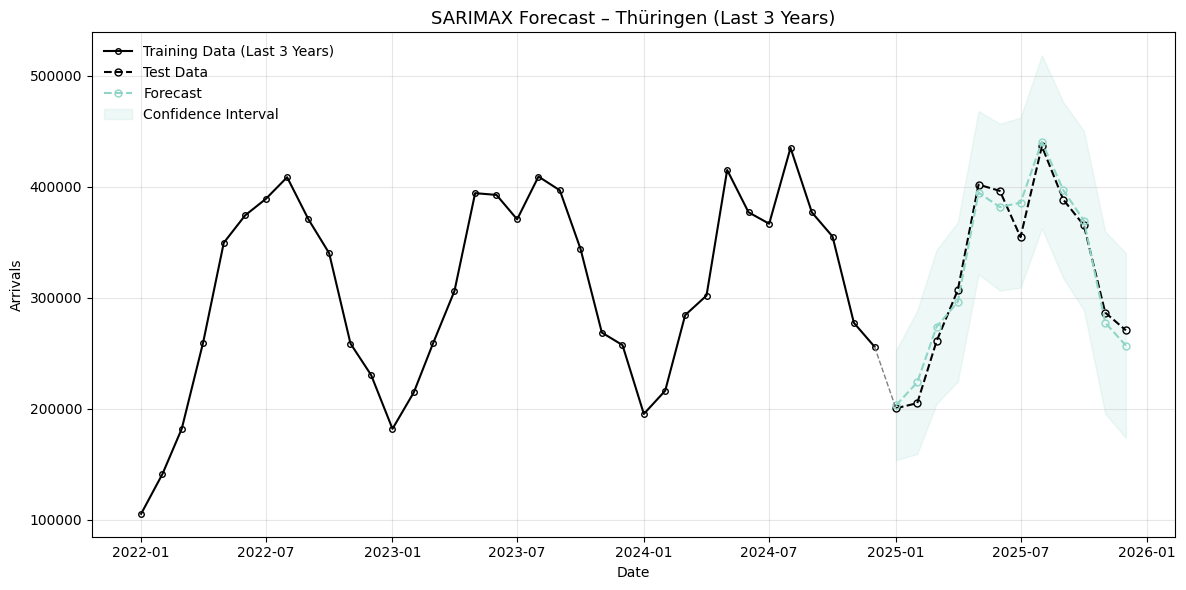

In [744]:
# ==================================================
# Plot SARIMAX forecast (zoomed view)
# ==================================================

plot_forecast_zoom(
    train_ts,
    test_ts,
    sarimax_df["forecast"],
    state_name,
    "SARIMAX",
    lower_ci=sarimax_df["lower_ci"],
    upper_ci=sarimax_df["upper_ci"]
)

## Best SARIMA or SARIMAX Models for Deployment

In [745]:
# ==================================================
# Compare SARIMA vs SARIMAX
# ==================================================

comparison = {
    "sarima": mape_sarima,
    "sarimax": mape_sarimax
}

best_model_type = min(comparison, key=comparison.get)

print("MAPE comparison:", comparison)
print(f"Best model for {state_name}: {best_model_type}")

MAPE comparison: {'sarima': 3.849278103172269, 'sarimax': 3.8051659835420297}
Best model for Thüringen: sarimax


## Forecast Model Comparison (Single State)

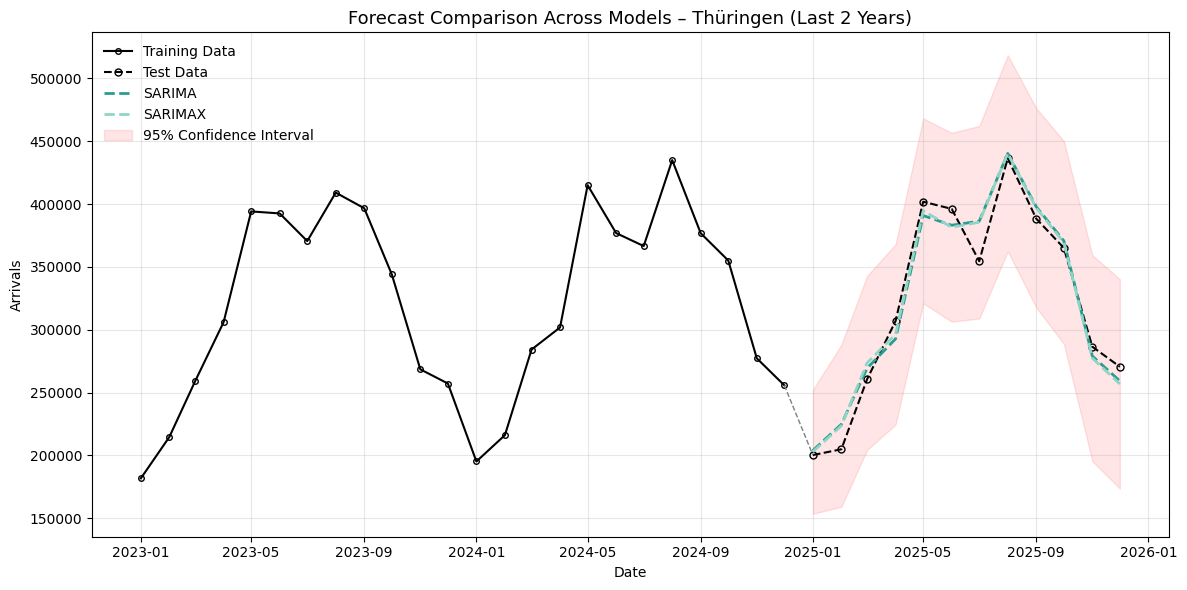

In [748]:
# --------------------------------------------------
# Plot comparison: All Models – Zoomed View (Last n Years)

n_years = 2
n_months = n_years * 12

plt.figure(figsize=(12,6))

# --------------------------------------------------
# Training data (last n years)

plt.plot(
    train_ts.index[-n_months:],
    train_ts[-n_months:],
    color="black",
    linewidth=1.5,
    marker="o",
    markersize=4,
    markerfacecolor="none",
    label="Training Data"
)

# --------------------------------------------------
# Test data

plt.plot(
    test_ts,
    color="black",
    linestyle="--",
    marker="o",
    markersize=5,
    markerfacecolor="none",
    label="Test Data"
)

# --------------------------------------------------
# SARIMA

plt.plot(
    sarima_df["forecast"],
    color=COLOR_MAP["SARIMA"],
    #color="red",
    linestyle="--",
    linewidth=2,
    label="SARIMA"
)

# --------------------------------------------------
# SARIMAX

plt.plot(
    sarimax_df["forecast"],
    color=COLOR_MAP["SARIMAX"],
    #color="blue",
    linestyle="--",
    linewidth=2,
    label="SARIMAX"
)


# --------------------------------------------------
# Confidence Interval
plt.fill_between(
    sarimax_df.index,
    sarimax_df['lower_ci'],
    sarimax_df['upper_ci'],
    color='red',
    alpha=0.1,
    label='95% Confidence Interval'
)

# --------------------------------------------------
# Connect training to test

plt.plot(
    [train_ts.index[-1], test_ts.index[0]],
    [train_ts.iloc[-1], test_ts.iloc[0]],
    linestyle="--",
    color="gray",
    linewidth=1
)

# --------------------------------------------------
# Title

plt.title(
    f"Forecast Comparison Across Models – {state_name} (Last {n_years} Years)",
    fontsize=13
)

plt.xlabel("Date")
plt.ylabel("Arrivals")

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

In [749]:
# --------------------------------------------------
# Build summary table for selected state

df_state_summary = pd.DataFrame({
    "Model": [
        "SARIMA",
        "SARIMAX"
    ],
    "MAPE": [
        mape_sarima,
        mape_sarimax
    ],
    "MAE": [
        mae_sarima,
        mae_sarimax
    ]
})

# --------------------------------------------------
# Highlight best MAPE

def highlight_best(row):

    best = df_state_summary["MAPE"].min()

    if row["MAPE"] == best:
        return ["background-color:#E8F5E9; font-weight:600"] * len(row)
    else:
        return [""] * len(row)
# --------------------------------------------------
# Create styled table with formatting and styles
# Note: This will display properly in Jupyter Notebook or similar environments that support DataFrame styling     

styled_table = (
    df_state_summary
    .style
    .apply(highlight_best, axis=1)
    .format({
        "MAPE": "{:.2f}",
        "MAE": "{:.0f}"
    })
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "16px"), ("text-align", "left")]},
        {"selector": "td", "props": [("font-size", "15px"), ("padding", "8px")]}
    ])
    .set_properties(**{
        "font-size": "15px",
        "border": "1px solid #ddd"
    })
)

# 

display(Markdown(f"#### **Forecast Model Performance — {state_name}**"))

styled_table

#### **Forecast Model Performance — Thüringen**

,Model,MAPE,MAE
0,SARIMA,3.85,11681
1,SARIMAX,3.81,11458


**Note:** The aggregate visualizations below require running the bundeshost
section for all 16 states first (so that `sarima_metrics` and `sarimax_metrics`
are populated for every state).

In [751]:

# ==================================================
# List states to show in final comparison
# ==================================================

states_to_show = sorted(df["state"].unique())
print("States to show:", states_to_show)    

States to show: ['Baden-Württemberg', 'Bayern', 'Berlin', 'Brandenburg', 'Bremen', 'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen', 'Nordrhein-Westfalen', 'Rheinland-Pfalz', 'Saarland', 'Sachsen', 'Sachsen-Anhalt', 'Schleswig-Holstein', 'Thüringen']


In [752]:
from IPython.display import display, Markdown


# --------------------------------------------------
# Loop over states

for state in states_to_show:

    if state not in sarima_metrics:
        continue

    # --------------------------------------------------
    # Build dataframe

    df_deploy = pd.DataFrame({
        "Model": [
            "SARIMA",
            "SARIMAX"
        ],
        "MAPE": [
            sarima_metrics[state]["MAPE"],
            sarimax_metrics[state]["MAPE"]
        ],
        "MAE": [
            sarima_metrics[state]["MAE"],
            sarimax_metrics[state]["MAE"]
        ]
    })
    df_deploy.index = df_deploy.index + 1


    # --------------------------------------------------
    # Styling function (color per model + highlight best)

    def style_rows(row):
        model = row["Model"]
        best = df_deploy["MAPE"].min()

        base_color = COLOR_MAP.get(model, "")

        # normal colored rows
        if base_color:
            return [f"background-color:{base_color}; color:white"] * len(row)

        return [""] * len(row)


    # --------------------------------------------------
    # Styled table

    styled_table = (
        df_deploy
        .style
        .apply(style_rows, axis=1)
        .format({
            "MAPE": "{:.2f}",
            "MAE": "{:.0f}"
        }, na_rep="—")
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#F3F4F6"),
                    ("font-size", "15px"),
                    ("text-align", "right"),
                    ("border-bottom", "2px solid #9CA3AF")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "10px 20px"),
                    ("font-size", "14px"),
                    ("border-bottom", "1px solid #E5E7EB")
                ]
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("width", "360px")
                ]
            }
        ])
    )


    # --------------------------------------------------
    # Display
    display(Markdown(f"#### **Comparing Models — {state}**"))
    #display(Markdown(f"#### **Deployment Forecast Performance — {state}**"))
    display(styled_table)

#### **Comparing Models — Baden-Württemberg**

,Model,MAPE,MAE
1,SARIMA,4.43,84424
2,SARIMAX,4.63,86653


#### **Comparing Models — Bayern**

,Model,MAPE,MAE
1,SARIMA,6.03,183937
2,SARIMAX,4.70,139251


#### **Comparing Models — Berlin**

...

,Model,MAPE,MAE
1,SARIMA,4.26,11862
2,SARIMAX,4.19,11865


#### **Comparing Models — Schleswig-Holstein**

,Model,MAPE,MAE
1,SARIMA,5.97,46565
2,SARIMAX,5.89,43350


#### **Comparing Models — Thüringen**

,Model,MAPE,MAE
1,SARIMA,3.85,11681
2,SARIMAX,3.81,11458


## Aggregate model performance across all states

In [753]:
# ---------------------------------------
# Aggregate model performance across all states

import numpy as np
import pandas as pd
from IPython.display import display, Markdown


summary_rows = []

models_dict = {
    "SARIMA": sarima_metrics,
    "SARIMAX": sarimax_metrics
}

for model_name, metrics_dict in models_dict.items():

    mape_vals = []
    mae_vals = []

    for state in states_to_show:
        if state in metrics_dict:
            mape_vals.append(metrics_dict[state]["MAPE"])
            mae_vals.append(metrics_dict[state]["MAE"])

    summary_rows.append({
        "Model": model_name,
        "Avg MAPE": np.mean(mape_vals),
        "Avg MAE": np.mean(mae_vals)
    })


df_summary = pd.DataFrame(summary_rows)


# ---------------------------------------
# Highlight best model (lowest Avg MAPE)

def highlight_best_summary(row):
    best = df_summary["Avg MAPE"].min()
    if pd.notnull(row["Avg MAPE"]) and row["Avg MAPE"] == best:
        return ["background-color:#F0DBF5;font-weight:600"] * len(row)
    return [""] * len(row)

df_summary = df_summary.sort_values("Avg MAPE")

styled_summary = (
    df_summary
    .style
    .apply(highlight_best_summary, axis=1)
    .format({
        "Avg MAPE": "{:.2f}",
        "Avg MAE": "{:.0f}"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#F3F4F6"),
                ("font-size", "15px"),
                ("text-align", "left"),
                ("border-bottom", "2px solid #9CA3AF")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px"),
                ("font-size", "14px"),
                ("border-bottom", "1px solid #E5E7EB")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("width", "420px")
            ]
        }
    ])
)


display(Markdown("### Overall Model Performance Across All States"))
display(styled_summary)

### Overall Model Performance Across All States

,Model,Avg MAPE,Avg MAE
1,SARIMAX,4.80,43130
0,SARIMA,5.06,48514


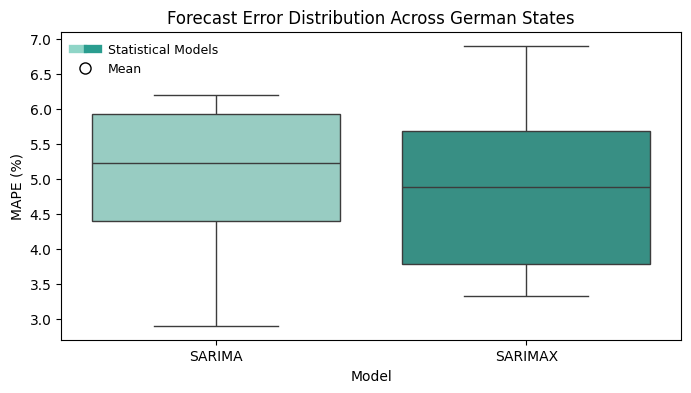

In [769]:
# ---------------------------------------
# Prepare dataframe for boxplot (MAPE distribution across states)

box_rows = []

for model_name, metrics_dict in models_dict.items():
    
    for state in states_to_show:
        
        if state in metrics_dict:
            
            box_rows.append({
                "Model": model_name,
                "State": state,
                "MAPE": metrics_dict[state]["MAPE"]
            })

df_box = pd.DataFrame(box_rows)


# ---------------------------------------
# Boxplot of model stability across states

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
palette = [COLOR_MAP[m] for m in df_summary["Model"]]

sns.boxplot(
    data=df_box,
    x="Model",
    y="MAPE",
    palette=palette,
    #showfliers=True,
    #flierprops={"marker": "o", "markersize": 6, "markerfacecolor": "none", "markeredgecolor": "red", "markeredgewidth": 1.5}    
)

plt.xticks(rotation=0)
plt.ylabel("MAPE (%)")
plt.xlabel("Model")
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# --- Statistical (SARIMA / SARIMAX)
stat_lines = (
    Line2D([0], [0], color="#8FD5C7", lw=6),
    Line2D([0], [0], color="#2A9D8F", lw=6)
)


# --- Other elements
legend_elements = [

    (stat_lines, "Statistical Models"),

    (Line2D([0], [0],
            marker='o',
            color='black',
            markerfacecolor='white',
            linestyle='None',
            markersize=8),
     "Mean")
]

# unpack
handles, labels = zip(*legend_elements)

plt.legend(
    handles,
    labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc="upper left",
    frameon=False,
    fontsize=9
)

plt.title("Forecast Error Distribution Across German States")

plt.show()

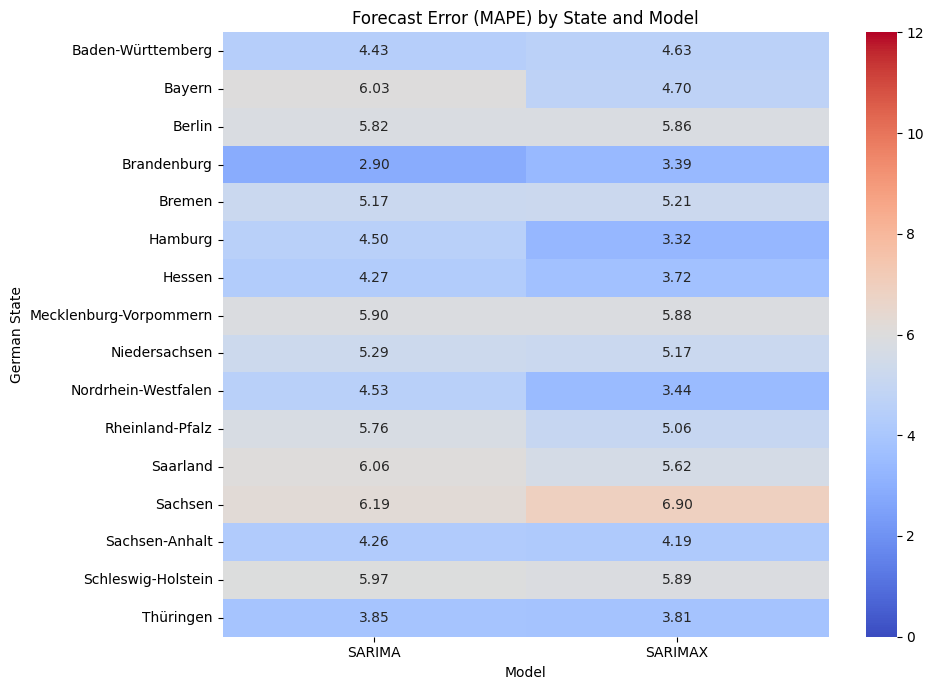

In [756]:
# ---------------------------------------
# Create pivot table for heatmap

df_heatmap = df_box.copy()

pivot_heatmap = df_heatmap.pivot(
    index="State",
    columns="Model",
    values="MAPE"
)
pivot_heatmap = df_heatmap.pivot(
    index="State",
    columns="Model",
    values="MAPE"
)

# ---------------------------------------
# Set desired model order for X-axis

model_order = [
    "SARIMA",
    "SARIMAX"
]

pivot_heatmap = pivot_heatmap[model_order]


# ---------------------------------------
# Plot heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

sns.heatmap(
    pivot_heatmap,
    annot=True,
    fmt=".2f",
    #cmap="RdYlGn_r",
    #cmap="YlGnBu",
    #cmap = sns.light_palette("#864B92", as_cmap=True),
    cmap="coolwarm",
    vmin=0,
    vmax=12
)

plt.title("Forecast Error (MAPE) by State and Model")
plt.xlabel("Model")
plt.ylabel("German State")

plt.tight_layout()
plt.show()

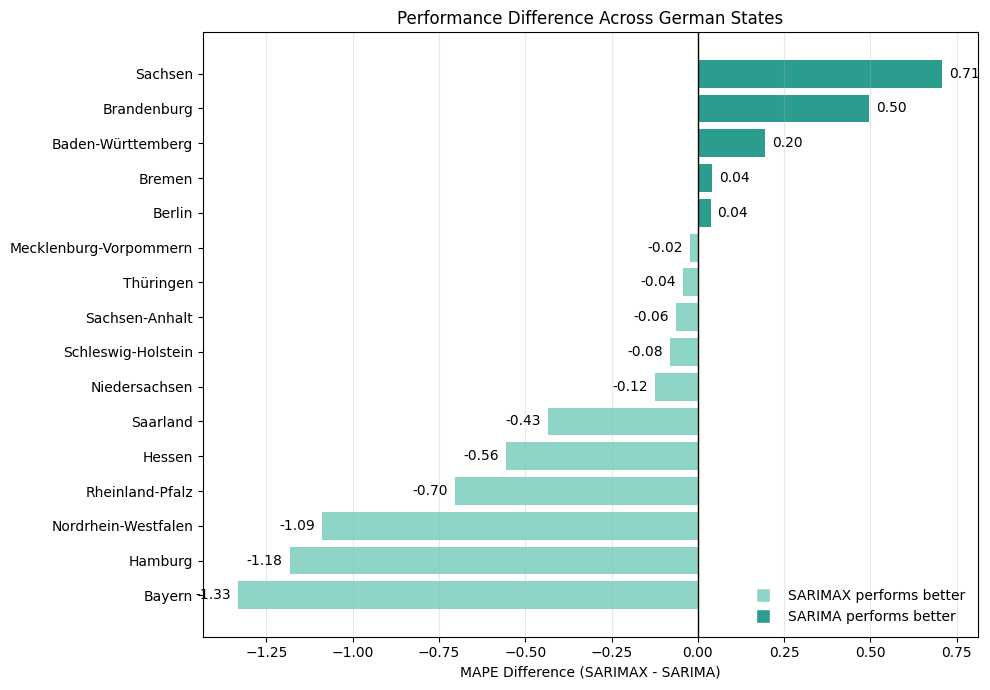

In [757]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------------------
# Build dataframe

rows = []

for state in states_to_show:
    if state not in sarima_metrics:
        continue

    sarima = sarima_metrics[state]["MAPE"]
    sarimax = sarimax_metrics[state]["MAPE"]

    rows.append({
        "State": state,
        "Diff": sarimax - sarima
    })

df_diff = pd.DataFrame(rows)

# sort for better visualization
df_diff = df_diff.sort_values("Diff")

# ---------------------------------------
# Plot

plt.figure(figsize=(10,7))

colors = [
    "#2A9D8F" if x > 0 else "#8FD5C7"
    for x in df_diff["Diff"]
]

bars = plt.barh(
    df_diff["State"],
    df_diff["Diff"],
    color=colors
)

# vertical zero line
plt.axvline(0, color="black", linewidth=1)

# ---------------------------------------
# Add value labels

for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    if width >= 0:
        plt.text(width + 0.02, y, f"{width:.2f}", va='center')
    else:
        plt.text(width - 0.02, y, f"{width:.2f}", va='center', ha='right')

# ---------------------------------------
# Legend (interpretation, not model names)

legend_elements = [
    Line2D([0], [0], marker='s', color='w',
           label='SARIMAX performs better',
           markerfacecolor="#8FD5C7", markersize=10),

    Line2D([0], [0], marker='s', color='w',
           label='SARIMA performs better',
           markerfacecolor="#2A9D8F", markersize=10)
]
"#8FD5C7"
plt.legend(
    handles=legend_elements,
    frameon=False,
    loc="lower right"
)

# ---------------------------------------
# Labels & styling

plt.xlabel("MAPE Difference (SARIMAX - SARIMA)")
plt.title("Performance Difference Across German States")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [758]:
# ---------------------------------------
# Prepare data for range plot

range_rows = []

for model_name, metrics_dict in models_dict.items():

    mape_vals = []

    for state in states_to_show:
        if state in metrics_dict:
            mape_vals.append(metrics_dict[state]["MAPE"])

    if len(mape_vals) > 0:
        range_rows.append({
            "Model": model_name,
            "Min": np.min(mape_vals),
            "Max": np.max(mape_vals),
            "Mean": np.mean(mape_vals)
        })

df_range = pd.DataFrame(range_rows)


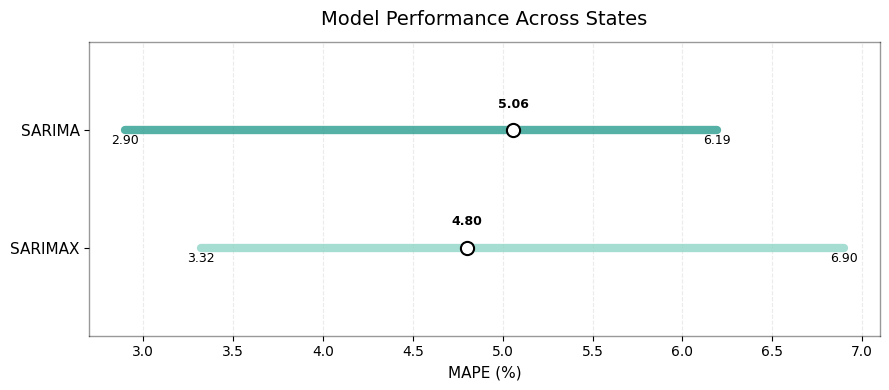

In [767]:
# ---------------------------------------
# Sort (best → worst)

df_range = (
    df_range
    .sort_values("Mean", ascending=True)
    .reset_index(drop=True)
)

# ---------------------------------------
# Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))

# custom vertical positions
y_positions = [0.38, 0.62]

for i, (_, row) in enumerate(df_range.iterrows()):

    y = y_positions[i]

    # range line
    plt.plot(
        [row["Min"], row["Max"]],
        [y, y],
        linewidth=6,
        alpha=0.8,
        color=COLOR_MAP[row["Model"]],
        solid_capstyle="round"
    )

    # mean point
    plt.scatter(
        row["Mean"],
        y,
        s=90,
        zorder=3,
        color="white",
        edgecolor="black",
        linewidth=1.5
    )

    # min label
    plt.text(
        row["Min"],
        y - 0.035,
        f"{row['Min']:.2f}",
        fontsize=9,
        ha="center",
        va="bottom"
    )

    # max label
    plt.text(
        row["Max"],
        y - 0.035,
        f"{row['Max']:.2f}",
        fontsize=9,
        ha="center",
        va="bottom"
    )

    # mean label
    plt.text(
        row["Mean"],
        y + 0.045,
        f"{row['Mean']:.2f}",
        fontsize=9,
        ha="center",
        fontweight="bold"
    )

# y labels
plt.yticks(
    y_positions,
    df_range["Model"],
    fontsize=11
)

# best model on top
plt.gca().invert_yaxis()

# keep both models centered
plt.ylim(0.2, 0.8)

# labels & title
plt.xlabel("MAPE (%)", fontsize=11)

plt.title(
    "Model Performance Across States",
    fontsize=14,
    pad=12
)

# grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

# frame styling
ax = plt.gca()

# outer box
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_alpha(0.4)

plt.tight_layout()
plt.show()

In [760]:

# Load Germany states GeoJSON
import geopandas as gpd

gdf = gpd.read_file("../data/2_hoch.geo.json")

gdf.head()

,id,name,type,geometry
0,DE-BW,Baden-Württemberg,State,"MULTIPOLYGON (((9.65046 49.77634, 9.65097 49.7..."
1,DE-BY,Bayern,State,"POLYGON ((10.13386 50.55, 10.1398 50.54252, 10..."
2,DE-BE,Berlin,State,"POLYGON ((13.16181 52.59442, 13.1801 52.59416,..."
3,DE-BB,Brandenburg,State,"POLYGON ((13.87951 53.50107, 13.87927 53.49908..."
4,DE-HB,Bremen,State,"POLYGON ((8.98545 53.12822, 8.97316 53.12799, ..."


Index(['id', 'name', 'type', 'geometry'], dtype='object')


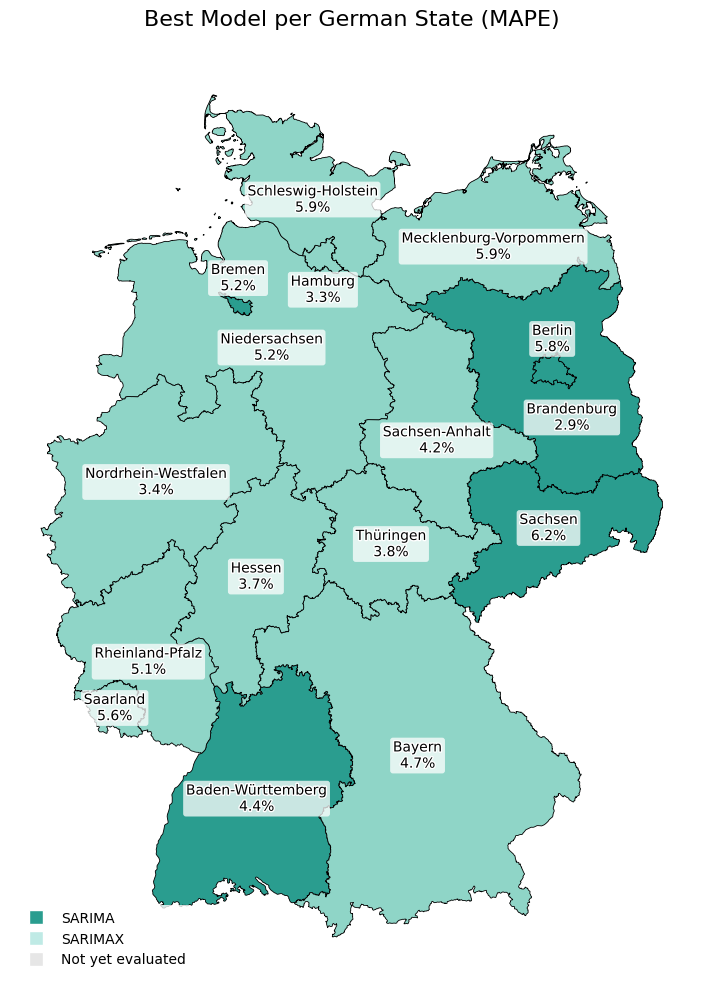

In [761]:

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# ---------------------------------------
# Build dataframe (best model + MAPE)

rows = []

for state in states_to_show:
    if state not in sarima_metrics:
        continue

    sarima = sarima_metrics[state]["MAPE"]
    sarimax = sarimax_metrics[state]["MAPE"]

    if sarima <= sarimax:
        best_model = "SARIMA"
        best_mape = sarima
    else:
        best_model = "SARIMAX"
        best_mape = sarimax

    rows.append({
        "state": state,
        "best_model": best_model,
        "MAPE": best_mape
    })

df_best = pd.DataFrame(rows)

# ---------------------------------------
# Load GeoJSON

gdf = gpd.read_file("../data/2_hoch.geo.json")

# ---------------------------------------
# Identify correct column name for states

print(gdf.columns)  # check once

STATE_COL = "name"  # adjust if needed

# ---------------------------------------
# Fix naming differences

state_map = {
    "Baden-Wuerttemberg": "Baden-Württemberg",
    "Thuringen": "Thüringen"
}

gdf[STATE_COL] = gdf[STATE_COL].replace(state_map)

# ---------------------------------------
# Merge

gdf_merged = gdf.merge(
    df_best,
    left_on=STATE_COL,
    right_on="state",
    how="left"
)

gdf_merged["color"] = gdf_merged["best_model"].map(COLOR_MAP).fillna("#E6E6E6")

# ---------------------------------------
# Plot

fig, ax = plt.subplots(1, 1, figsize=(8,10))

gdf_merged.plot(
    color=gdf_merged["color"],
    edgecolor="black",
    linewidth=0.6,
    ax=ax
)
"""
# ---------------------------------------
# Highlight Brandenburg

highlight_state = "Brandenburg"

row = gdf_merged[gdf_merged[STATE_COL] == highlight_state]

if not row.empty:
    row.plot(
        ax=ax,
        edgecolor="black",
        linewidth=2.5,
        facecolor="none"
    )
"""
# ---------------------------------------
# Custom offsets for small states

offsets = {
    "Berlin": (0.0, 0.3),
    "Hamburg": (0.0, -0.3),
    "Bremen": (-0.01, 0.25),
    "Brandenburg": (0.3, -0.4),
    "Niedersachsen": (0.1, -0.05),
    "Rheinland-Pfalz": (0.0, -0.1),
    "Mecklenburg-Vorpommern": (0.0, -0.1),
    "Sachsen-Anhalt": (0.0, -0.15),
    "Schleswig-Holstein": (0.07, -0.1)
}

# ---------------------------------------
# Add labels (state + MAPE)

for idx, row in gdf_merged.iterrows():
    if row["geometry"] is None:
        continue

    x, y = row["geometry"].centroid.x, row["geometry"].centroid.y
    state_name = row[STATE_COL]

    dx, dy = offsets.get(state_name, (0, 0))

    if pd.notnull(row["MAPE"]):
        label = f"{state_name}\n{row['MAPE']:.1f}%"
    else:
        label = state_name

    text = ax.text(
        x + dx,
        y + dy,
        label,
        ha='center',
        va='center',
        fontsize=10,
        #fontweight="bold",
        color="black",
        bbox=dict(
            facecolor="white",
            alpha=0.75,
            edgecolor="none",
            boxstyle="round,pad=0.2"
        )
    )

    # white outline for readability
    text.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground="white"),
        path_effects.Normal()
    ])

# ---------------------------------------
# Legend

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='s', color='w',
           label='SARIMA',
           markerfacecolor="#2A9D8F", markersize=10),

    Line2D([0], [0], marker='s', color='w',
           label='SARIMAX',
           markerfacecolor="#BFEAE5", markersize=10)
]
legend_elements.append(
    Line2D([0], [0],
           marker='s',
           color='w',
           label="Not yet evaluated",
           markerfacecolor="#E6E6E6",
           markersize=10)
)
ax.legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="none"
)

# ---------------------------------------
# Title & layout

ax.set_title(
    "Best Model per German State (MAPE)",
    fontsize=16,
    #fontweight="bold",
    pad=20
)

ax.axis("off")

plt.tight_layout()
plt.show()


---

## 💾 Saving Models for Deployment

Inspection above is for **exploration only**. To save the production
models used by the Streamlit app, run the following commands in the
terminal from the project root:

```bash
# Train SARIMA + SARIMAX on the full dataset (16 states × 2 models = 32 .pkl files)
python -m bundeshost.train

# Evaluate both models on the test set, pick the best per state,
# and save the selection to models/best_models.json
python -m bundeshost.evaluate
```

The Streamlit app loads models from `models/` and uses `best_models.json`
to know which one to use for each state.

---